In [12]:
#Este código realiza una regresión lineal de la relación entre el peso de un
#vehículo y el consumo de combustible
!pip install ucimlrepo

In [13]:
#Base de datos extraída de UCI Machine Learning Repository
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#Toma y limpia un DataFrame que contiene el peso y el mpg (millas por galón)
df = pd.concat([X, y], axis=1).dropna(subset=['weight', 'mpg'])
x = df['weight']
y_data = df['mpg']

#Inicialización de las sumatorias
n = len(x)

suma_xi   = 0
suma_yi   = 0
suma_xixi = 0
suma_xiyi = 0

#Cálculo de las sumatorias con un ciclo for
for i in range(n):
    suma_xi   += x[i]
    suma_yi   += y_data[i]
    suma_xixi += x[i]**2
    suma_xiyi += x[i] * y_data[i]

#Aplicación de las ecuaciones para intercepto (b) y pendiente (m)
denominador = (n * suma_xixi - suma_xi**2)
m = (n * suma_xiyi - suma_xi * suma_yi) / denominador
b = (suma_xixi * suma_yi - suma_xiyi * suma_xi) / denominador

#Recta resultante
L = m * x + b

#Cálculo del coeficiente de determinación
media_x = suma_xi / n
media_y = suma_yi / n
numerador_r2 = 0
denominador_x = 0
denominador_y = 0

#Mediante un ciclo for aplicamos la ecuación
for i in range(n):
    # (xi - media_x) * (yi - media_y)
    numerador_r2 += (x[i] - media_x) * (y_data[i] - media_y)

    # (xi - media_x)^2
    denominador_x += (x[i] - media_x)**2

    # (yi - media_y)^2
    denominador_y += (y_data[i] - media_y)**2


r = numerador_r2 / ( (denominador_x * denominador_y)**0.5 )
#Coeficiente de determinación
r2 = r**2

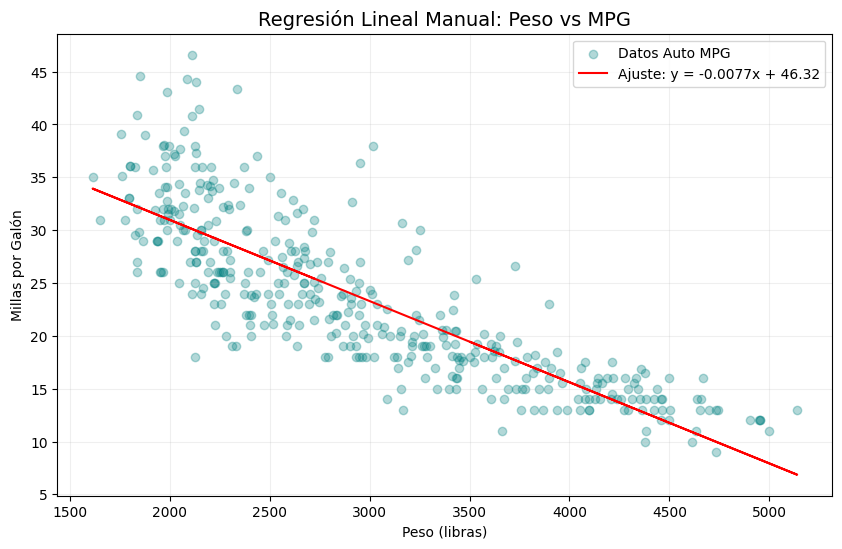

Resultados calculados:
m = -0.007676610063926486
b = 46.3173644202657
Coeficiente de Correlación (r): -0.8317
Coeficiente de Determinación (R²): 0.6918


In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y_data, color='teal', alpha=0.3, label='Datos Auto MPG')
plt.plot(x, L, color='red', label=f'Ajuste: y = {m:.4f}x + {b:.2f}')

plt.title('Regresión Lineal Manual: Peso vs MPG', fontsize=14)
plt.xlabel('Peso (libras)')
plt.ylabel('Millas por Galón')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Resultados calculados:\nm = {m}\nb = {b}")
print(f"Coeficiente de Correlación (r): {r:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

In [17]:
# DataFrame con las dos variables usadas
tabla_datos = pd.DataFrame({
    'Peso (lb)': x,
    'Consumo (MPG)': y_data
})

# Mostrar los primeros 10 registros
print("Muestra de los datos utilizados:")
print(tabla_datos.head(10).to_string(index=False))

Muestra de los datos utilizados:
 Peso (lb)  Consumo (MPG)
      3504           18.0
      3693           15.0
      3436           18.0
      3433           16.0
      3449           17.0
      4341           15.0
      4354           14.0
      4312           14.0
      4425           14.0
      3850           15.0
